# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [36]:
df = pd.read_csv("data/reviews_sentiment.csv", sep=';')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    object 
 1   Review Text     257 non-null    object 
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    object 
 4   textSentiment   257 non-null    object 
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), object(4)
memory usage: 14.2+ KB


In [38]:
df.head()

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784


In [39]:
df.columns

Index(['Review Title', 'Review Text', 'wordcount', 'titleSentiment',
       'textSentiment', 'Star Rating', 'sentimentValue'],
      dtype='object')

In [40]:
df.isna().any().any()

np.True_

In [41]:
df.isna().sum()

Review Title       0
Review Text        0
wordcount          0
titleSentiment    26
textSentiment      0
Star Rating        0
sentimentValue     0
dtype: int64

In [42]:
df["sentimentValue"].describe()

count    257.000000
mean       0.383849
std        0.897987
min       -2.276469
25%       -0.108144
50%        0.264091
75%        0.808384
max        3.264579
Name: sentimentValue, dtype: float64

In [43]:
df["Star Rating"].describe()

count    257.000000
mean       3.420233
std        1.409531
min        1.000000
25%        3.000000
50%        3.000000
75%        5.000000
max        5.000000
Name: Star Rating, dtype: float64

In [44]:
df["Star Rating"].value_counts().sort_index()

Star Rating
1    37
2    24
3    78
4    30
5    88
Name: count, dtype: int64

In [45]:
df["textSentiment"].describe()

count          257
unique           2
top       positive
freq           211
Name: textSentiment, dtype: object

## Análisis  textSentiment es una variable categórica binaria con dos categorías, y está muy desbalanceada:
- positive: 211 veces
- negative: 257 - 211 = 46 veces

* Es decir, alrededor del 82% de los datos son "positive".

## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

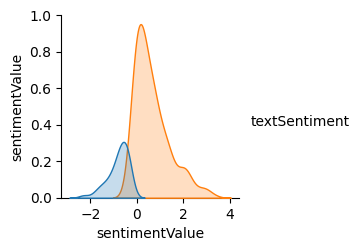

In [14]:

sns.pairplot(df, vars=["sentimentValue"],hue="textSentiment")


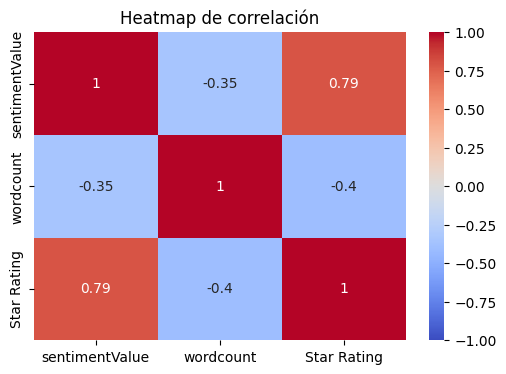

In [15]:
col_corr_1 = ["sentimentValue", "wordcount","Star Rating"]

corr = df[col_corr_1].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Heatmap de correlación")
plt.show()

Text(0, 0.5, 'Número de reseñas')

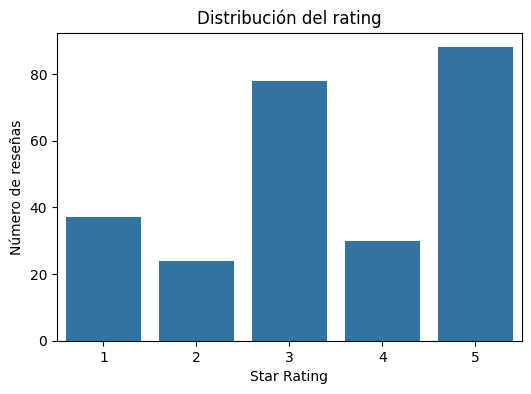

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Star Rating")
plt.title("Distribución del rating")
plt.xlabel("Star Rating")
plt.ylabel("Número de reseñas")

In [17]:
(df["Star Rating"].value_counts(normalize=True) * 100).round(2)


Star Rating
5    34.24
3    30.35
1    14.40
4    11.67
2     9.34
Name: proportion, dtype: float64

In [18]:
df[["Star Rating", "sentimentValue"]].corr()


,Star Rating,sentimentValue
Star Rating,1.00000,0.79218
sentimentValue,0.79218,1.00000


Text(0.5, 1.0, 'Relación entre sentimiento y rating')

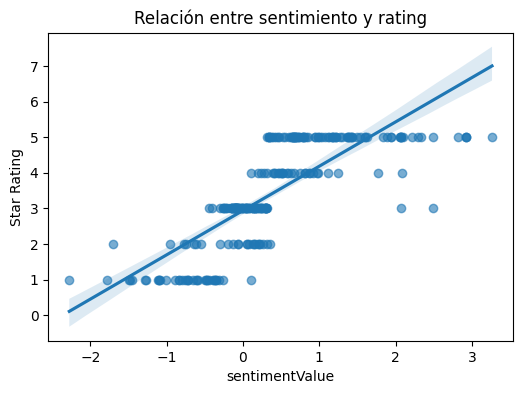

In [19]:
plt.figure(figsize=(6,4))
sns.regplot(
    data=df,
    x="sentimentValue",
    y="Star Rating",
    scatter_kws={"alpha": 0.6})

plt.title("Relación entre sentimiento y rating")

Text(0.5, 1.0, 'SentimentValue según textSentiment')

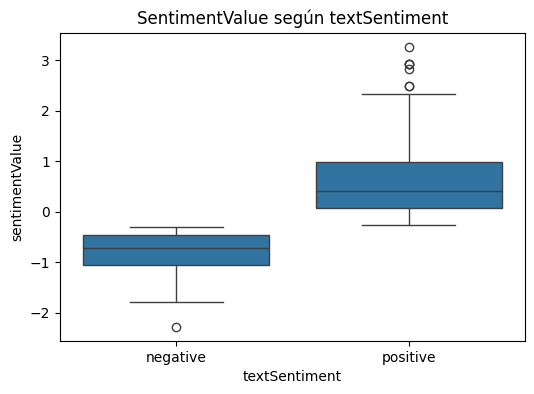

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="textSentiment", y="sentimentValue")
plt.title("SentimentValue según textSentiment")

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [21]:
df_model = df[["wordcount", "sentimentValue", "Star Rating"]]


In [22]:
X = df_model[["wordcount", "sentimentValue"]]
y = df_model["Star Rating"]


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=11) 


In [24]:
print("Train features shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Train features shape: (205, 2)
Train target shape: (205,)
Test features shape: (52, 2)
Test target shape: (52,)


In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

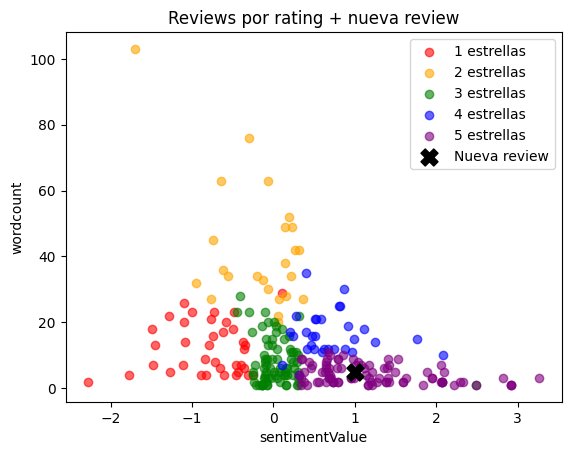

In [49]:
import matplotlib.pyplot as plt

# Nuevo punto: 5 palabras y sentimiento 1
punto_nuevo = {"wordcount": 5, "sentimentValue": 1}

ax = plt.axes()

# Colores para cada rating
colores = {
    1: "red",
    2: "orange",
    3: "green",
    4: "blue",
    5: "purple"
}

# Dibujamos un scatter por cada estrella
for rating, color in colores.items():
    ax.scatter(
        df_model.loc[df_model["Star Rating"] == rating, "sentimentValue"],
        df_model.loc[df_model["Star Rating"] == rating, "wordcount"],
        c=color,
        label=f"{rating} estrellas",
        alpha=0.6
    )

# Dibujamos el punto nuevo
ax.scatter(
    punto_nuevo["sentimentValue"],
    punto_nuevo["wordcount"],
    c="black",
    s=150,
    marker="X",
    label="Nueva review"
)

plt.xlabel("sentimentValue")
plt.ylabel("wordcount")
plt.title("Reviews por rating + nueva review")
ax.legend()
plt.show()


## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)



,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Evalúa tu modelo

In [27]:
y_pred = knn.predict(X_test_scaled)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8461538461538461


In [29]:
print("\nClassification report:\n", classification_report(y_test, y_pred))


Classification report:
               precision    recall  f1-score   support

           1       0.88      0.88      0.88         8
           2       0.71      0.83      0.77         6
           3       0.78      0.93      0.85        15
           4       1.00      0.43      0.60         7
           5       0.94      0.94      0.94        16

    accuracy                           0.85        52
   macro avg       0.86      0.80      0.81        52
weighted avg       0.86      0.85      0.84        52



In [30]:
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))


Matriz de confusión:
 [[ 7  1  0  0  0]
 [ 0  5  1  0  0]
 [ 1  0 14  0  0]
 [ 0  1  2  3  1]
 [ 0  0  1  0 15]]


## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [31]:
k_values = range(3, 22, 2)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

for k, score in zip(k_values, scores):
    print(f"k = {k}: accuracy = {score:.4f}")

k = 3: accuracy = 0.8462
k = 5: accuracy = 0.8462
k = 7: accuracy = 0.8077
k = 9: accuracy = 0.8077
k = 11: accuracy = 0.7692
k = 13: accuracy = 0.8269
k = 15: accuracy = 0.7885
k = 17: accuracy = 0.7885
k = 19: accuracy = 0.7692
k = 21: accuracy = 0.7692


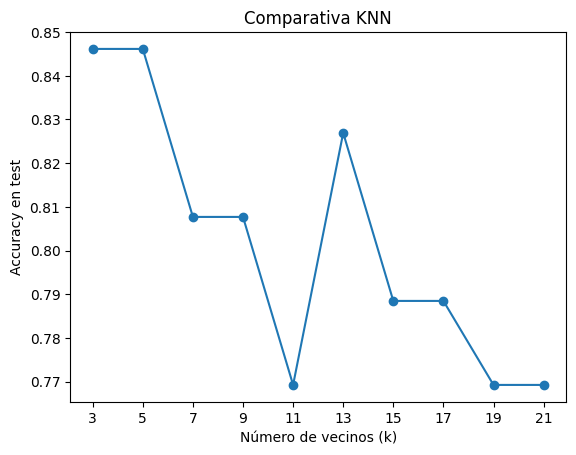

In [32]:
plt.plot(k_values, scores, marker="o")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy en test")
plt.title("Comparativa KNN")
plt.xticks(k_values)
plt.show()

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [33]:
nuevo = np.array([[5,3]])

nuevo_scaled = scaler.transform(nuevo)

prediccion = knn.predict(nuevo_scaled)
print("Rating predicho:", prediccion[0])

Rating predicho: 5


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
pruebas = knn.predict_proba(nuevo_scaled)
print("Probabilidades por clase (ordenadas como knn.classes_):")
print("Clases:", knn.classes_)
print("Probabilidades:", pruebas[0])


Probabilidades por clase (ordenadas como knn.classes_):
Clases: [1 2 3 4 5]
Probabilidades: [0.         0.         0.0952381  0.0952381  0.80952381]


In [47]:
param_grid = {"n_neighbors": list(range(3, 42, 2))}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy (CV):", grid.best_score_)

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print("Accuracy en test:", accuracy_score(y_test, y_pred))

Mejores parámetros: {'n_neighbors': 5}
Mejor accuracy (CV): 0.8680952380952383
Accuracy en test: 0.8461538461538461
